# Исследование факторов профессионального выгорания разработчиков ПО

## Поиск и выбор набора данных для построения моделей машинного обучения

В качестве набора данных используется датасет, посвящённый исследованию факторов, влияющих на профессиональное выгорание (burnout) у разработчиков программного обеспечения.

**Источник данных:** [указать источник, например Kaggle]

**Актуальность задачи:** Профессиональное выгорание — серьёзная проблема в IT-индустрии. Понимание факторов, ведущих к выгоранию, позволяет HR-специалистам и тимлидам своевременно выявлять сотрудников из группы риска и принимать превентивные меры.

**Описание датасета:**
- 7000 записей о разработчиках
- 12 колонок, включая демографические данные, рабочие метрики, показатели образа жизни и целевые переменные

**Колонки датасета:**
- `age` — возраст разработчика (float)
- `experience_years` — опыт работы в годах (float)
- `daily_work_hours` — количество рабочих часов в день (float)
- `sleep_hours` — количество часов сна (float)
- `caffeine_intake` — потребление кофеина в условных единицах (float)
- `bugs_per_day` — количество багов в день (float)
- `commits_per_day` — количество коммитов в день (float)
- `meetings_per_day` — количество встреч в день (float)
- `screen_time` — время перед экраном в часах (float)
- `exercise_hours` — количество часов физических упражнений (float)
- `stress_level` — уровень стресса в процентах (float, 0-100)
- `burnout_level` — уровень выгорания: 'Low', 'Medium', 'High' (string)

**Решаемые задачи:**
- **Задача классификации (основная):** предсказание уровня выгорания `burnout_level` (Low/Medium/High) — мультиклассовая классификация
- **Задача регрессии (дополнительная):** предсказание числового уровня стресса `stress_level`

## Импорт библиотек

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
%matplotlib inline
sns.set(style="ticks")
import warnings
warnings.filterwarnings('ignore')
print('Библиотеки успешно импортировны!')

Библиотеки успешно импортировны!


## Загрузка данных

In [4]:
# Загрузка датасета (замените путь на актуальный)
df = pd.read_csv('developer_burnout_dataset_7000.csv')

# Создадим копию для безопасной работы
data = df.copy()

# Удалим дубликаты записей, если они присутствуют
print(f'Размер датасета до удаления дубликатов: {data.shape}')
data = data.drop_duplicates()
print(f'Размер датасета после удаления дубликатов: {data.shape}')

Размер датасета до удаления дубликатов: (7000, 12)
Размер датасета после удаления дубликатов: (7000, 12)


## Проведение разведочного анализа данных (EDA)

### Основные характеристики датасета

In [5]:
# Первые 10 строк датасета
data.head(10)

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low
5,40.0,2.0,10.25,6.78,0.0,19.0,27.0,4.0,15.15,0.78,51.06,Medium
6,26.0,NaN,6.53,7.60,6.0,4.0,11.0,9.0,9.38,0.54,39.09,Medium
7,38.0,0.0,10.69,5.25,5.0,12.0,2.0,2.0,14.58,0.10,77.68,High
8,42.0,18.0,11.47,4.79,4.0,11.0,25.0,1.0,14.54,1.53,73.56,High
9,30.0,17.0,13.16,5.39,3.0,0.0,3.0,3.0,14.44,0.58,46.78,Medium


In [6]:
# Последние 10 строк датасета
data.tail(10)

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
6990,28.0,19.0,10.31,8.57,1.0,12.0,21.0,8.0,13.54,0.75,53.31,Medium
6991,21.0,1.0,5.38,6.80,5.0,10.0,10.0,3.0,8.81,NaN,42.12,Medium
6992,44.0,7.0,4.39,6.99,2.0,13.0,16.0,NaN,6.22,1.19,31.07,Low
6993,37.0,12.0,5.37,5.73,5.0,15.0,8.0,6.0,7.56,1.41,50.89,Medium
6994,28.0,19.0,6.86,5.86,2.0,5.0,25.0,2.0,8.29,0.04,32.26,Low
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44,Medium
6999,25.0,2.0,4.35,4.83,1.0,16.0,23.0,4.0,8.52,1.98,39.18,Medium


In [7]:
# Размер датасета
print(f'Количество строк: {data.shape[0]}')
print(f'Количество столбцов: {data.shape[1]}')
data.shape

Количество строк: 7000
Количество столбцов: 12


(7000, 12)

In [8]:
# Список колонок с типами данных
data.dtypes

age                 float64
experience_years    float64
daily_work_hours    float64
sleep_hours         float64
caffeine_intake     float64
bugs_per_day        float64
commits_per_day     float64
meetings_per_day    float64
screen_time         float64
exercise_hours      float64
stress_level        float64
burnout_level        object
dtype: object

In [9]:
# Базовая статистика по числовым признакам
data.describe()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


In [10]:
# Проверим наличие пустых значений
print("Количество пропущенных значений в каждой колонке:")
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data)) * 100
missing_df = pd.DataFrame({
    'Пропущено': missing_values,
    'Процент': missing_percent.round(2)
})
missing_df[missing_df['Пропущено'] > 0].sort_values('Пропущено', ascending=False)

Количество пропущенных значений в каждой колонке:


,Пропущено,Процент
age,140,2.0
experience_years,140,2.0
daily_work_hours,140,2.0
sleep_hours,140,2.0
caffeine_intake,140,2.0
bugs_per_day,140,2.0
commits_per_day,140,2.0
meetings_per_day,140,2.0
screen_time,140,2.0
exercise_hours,140,2.0


In [11]:
# Проверим также пустые строки в burnout_level (могут быть не только NaN, но и пустые строки)
empty_burnout = (data['burnout_level'] == '') | (data['burnout_level'].isna())
print(f"Строк с пустым burnout_level: {empty_burnout.sum()}")
print(f"Уникальные значения burnout_level: {data['burnout_level'].unique()}")

Строк с пустым burnout_level: 140
Уникальные значения burnout_level: ['Medium' 'High' 'Low' nan]


In [12]:
# Заменим пустые строки на NaN для единообразия
data['burnout_level'] = data['burnout_level'].replace('', np.nan)
print(f"Уникальные значения burnout_level после очистки: {data['burnout_level'].unique()}")

Уникальные значения burnout_level после очистки: ['Medium' 'High' 'Low' nan]


**Вывод:** В датасете присутствуют пропуски во всех колонках. Необходима тщательная предобработка данных.

### Визуализация распределений числовых признаков

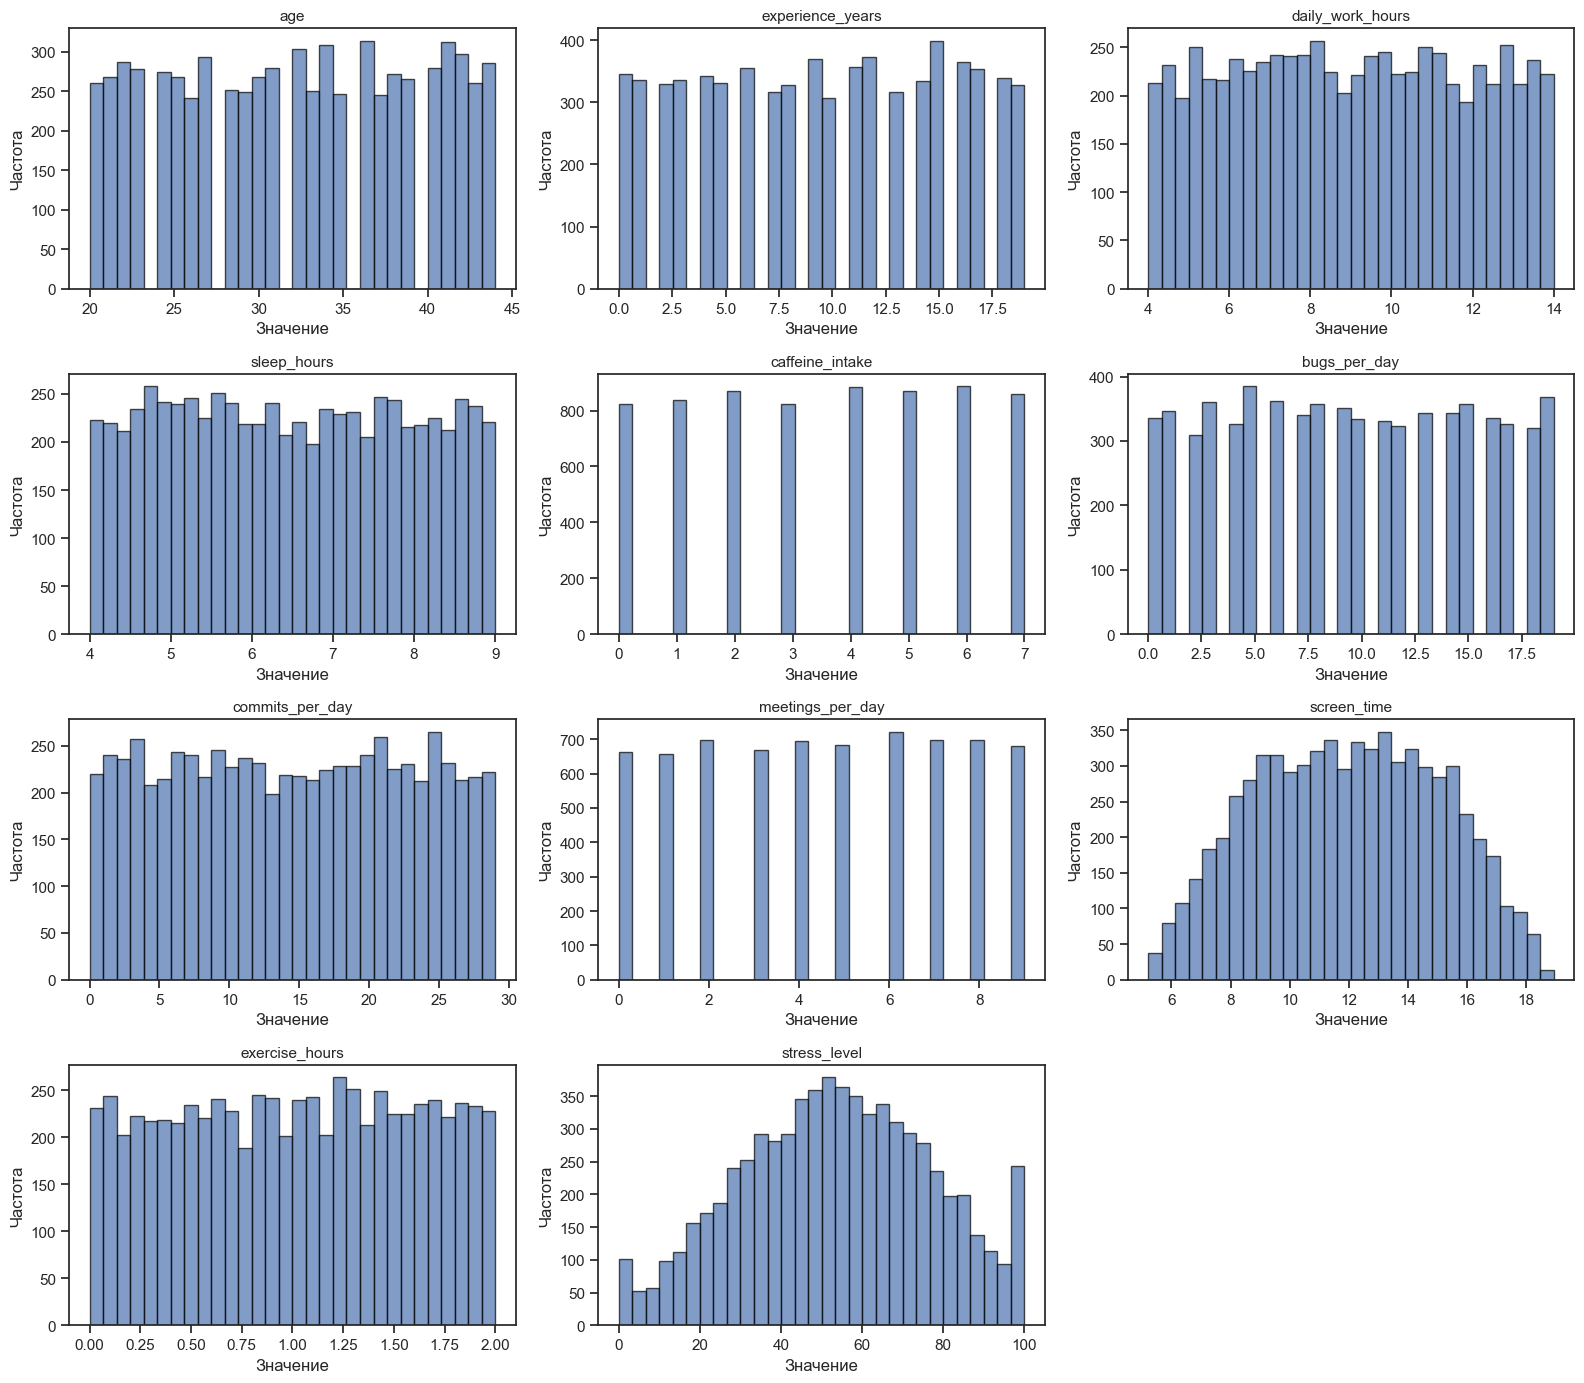

In [13]:
# Гистограммы для всех числовых признаков
numeric_cols = ['age', 'experience_years', 'daily_work_hours', 'sleep_hours',
                'caffeine_intake', 'bugs_per_day', 'commits_per_day',
                'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(data[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

# Убираем лишний пустой график (12-й)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

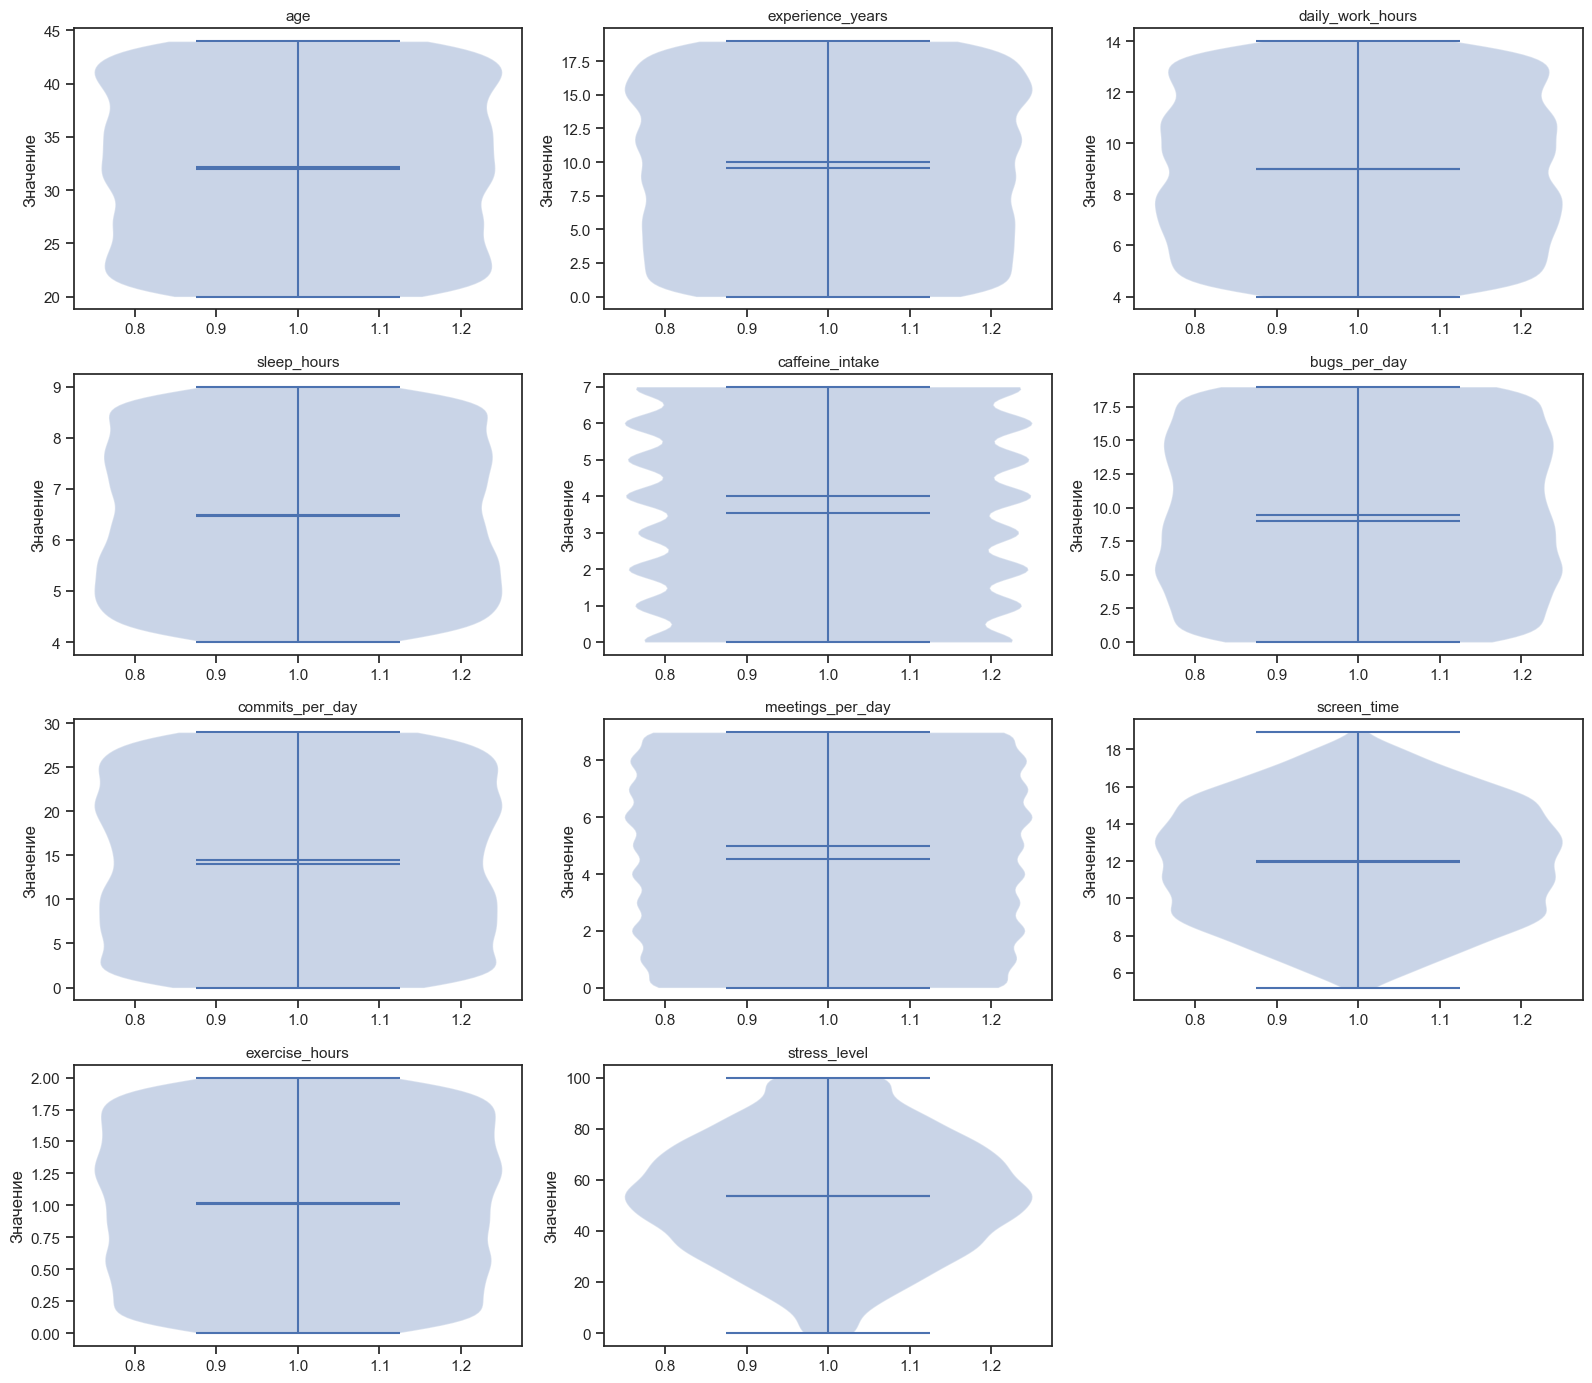

In [14]:
# Скрипичные диаграммы для числовых колонок
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].violinplot(data[col].dropna(), showmeans=True, showmedians=True)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Значение')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### Анализ целевой переменной (классификация)

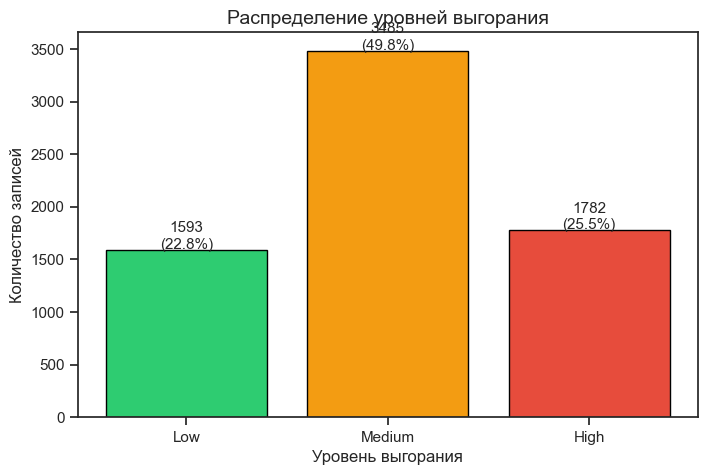

In [18]:
# Распределение классов burnout_level
plt.figure(figsize=(8, 5))

# Задаём правильный порядок: Low, Medium, High
category_order = ['Low', 'Medium', 'High']
burnout_counts = data['burnout_level'].value_counts().reindex(category_order)

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(burnout_counts.index, burnout_counts.values, color=colors, edgecolor='black')
plt.title('Распределение уровней выгорания', fontsize=14)
plt.xlabel('Уровень выгорания')
plt.ylabel('Количество записей')

# Подписи на столбцах
for bar, count in zip(bars, burnout_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}\n({count/len(data)*100:.1f}%)',
             ha='center', fontsize=11)
plt.show()

In [19]:
# Проверим баланс классов
total = len(data.dropna(subset=['burnout_level']))
for level in ['Low', 'Medium', 'High']:
    count = (data['burnout_level'] == level).sum()
    print(f"Класс '{level}': {count} записей ({count/total*100:.2f}%)")
print(f"\nОбщее количество записей с известным burnout_level: {total}")

Класс 'Low': 1593 записей (23.22%)
Класс 'Medium': 3485 записей (50.80%)
Класс 'High': 1782 записей (25.98%)

Общее количество записей с известным burnout_level: 6860


**Вывод:** Вывод. Дисбаланс классов присутствует, но является приемлемым.

### Визуализация взаимосвязей признаков с целевой переменной

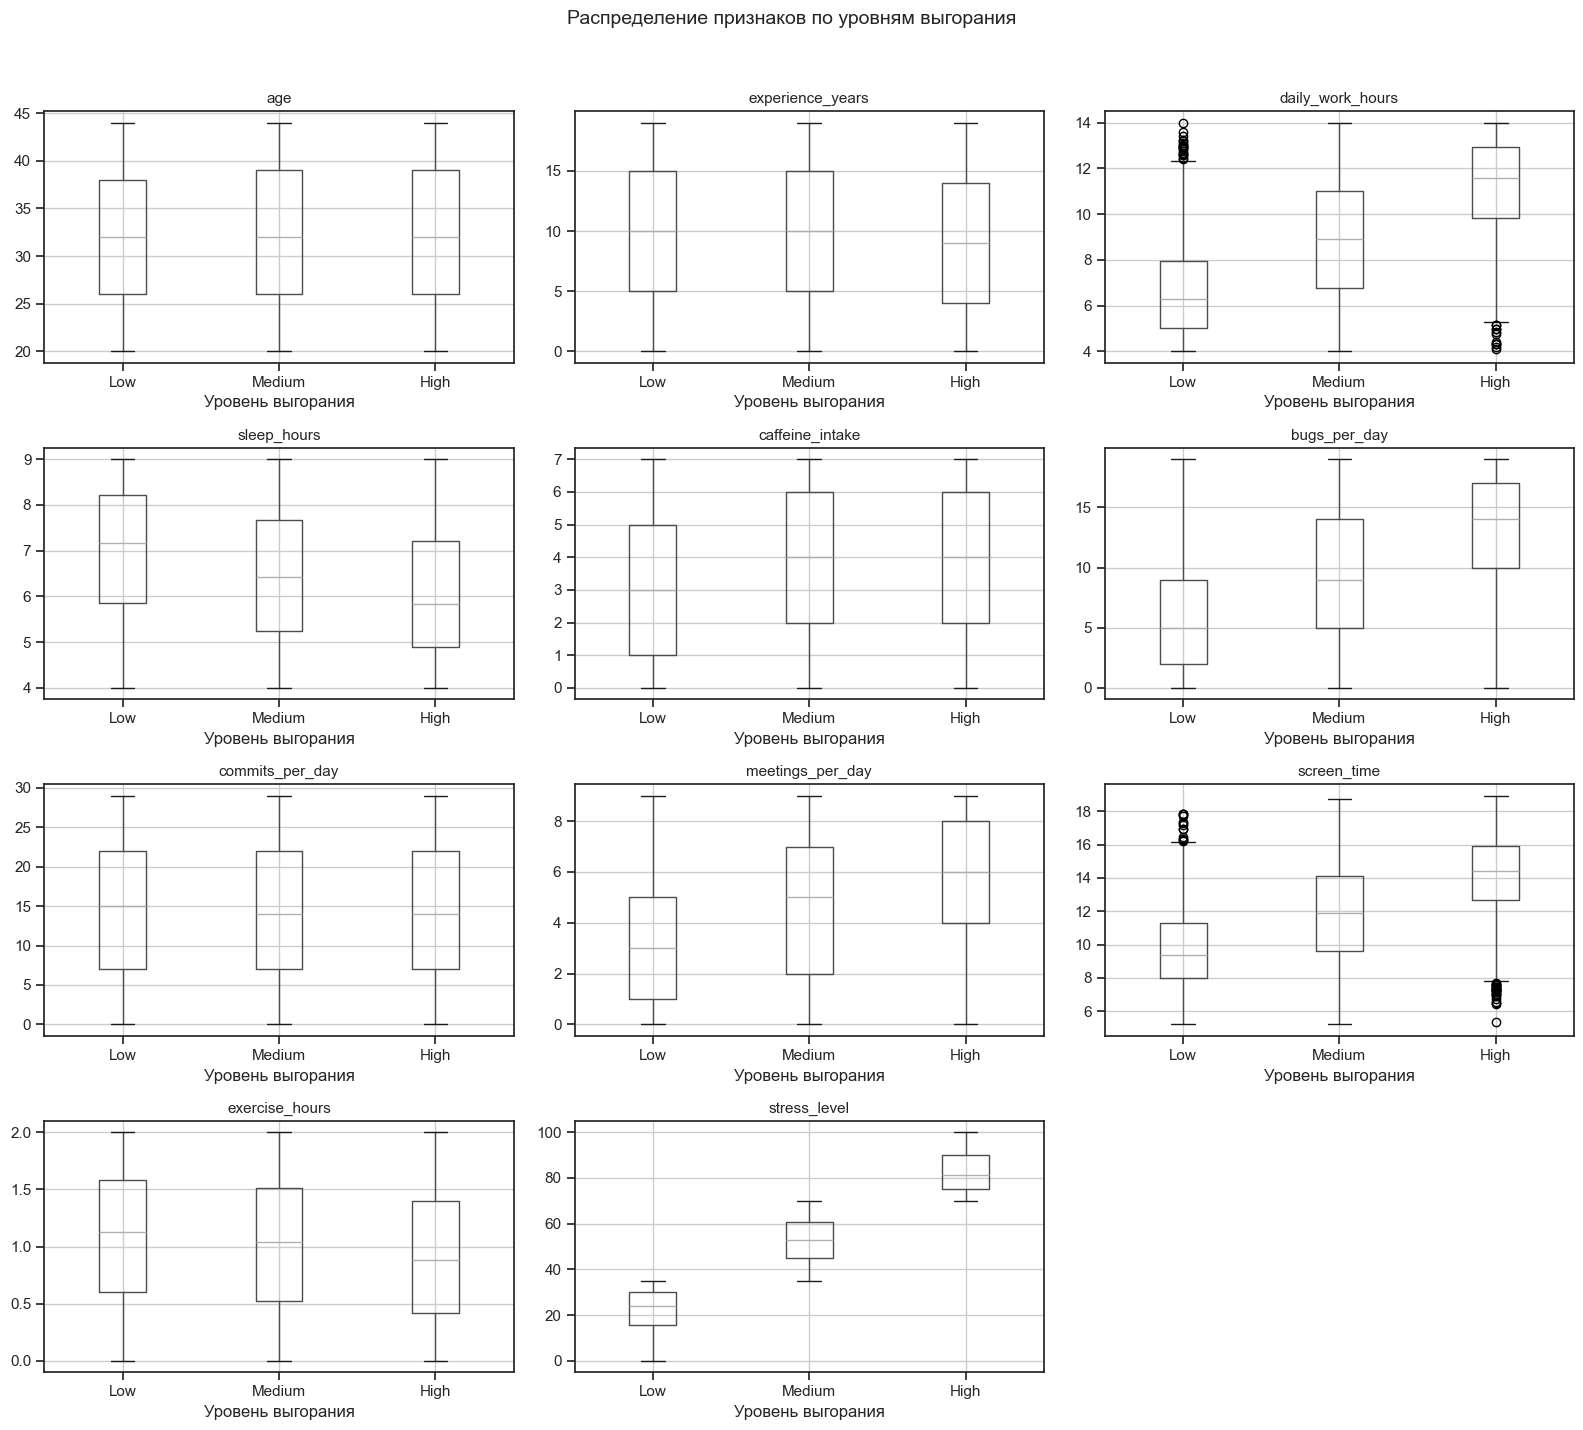

In [21]:
# Box-plot'ы для числовых признаков в разрезе burnout_level
data_with_target = data.dropna(subset=['burnout_level'])

category_order = ['Low', 'Medium', 'High']
data_with_target['burnout_level'] = pd.Categorical(
    data_with_target['burnout_level'], 
    categories=category_order, 
    ordered=True
)

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data_with_target.boxplot(column=col, by='burnout_level', ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Уровень выгорания')

axes[-1].set_visible(False)
plt.suptitle('Распределение признаков по уровням выгорания', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Наблюдения:**
- Разработчики с высоким уровнем выгорания (High) имеют тенденцию к более высокому `daily_work_hours`, `stress_level`, `screen_time`, `bugs_per_day`
- Уровень `sleep_hours` ниже у группы High
- `exercise_hours` также имеет тенденцию к снижению у выгоревших сотрудников

## Обработка пропусков

In [22]:
# Стратегия обработки пропусков:
# 1. Удаляем строки с пропущенным целевым признаком burnout_level (не можем использовать для обучения)
print(f"Размер до удаления строк с пустым burnout_level: {data.shape}")
data_clean = data.dropna(subset=['burnout_level']).copy()
print(f"Размер после удаления строк с пустым burnout_level: {data_clean.shape}")
print(f"Удалено строк: {data.shape[0] - data_clean.shape[0]}")

Размер до удаления строк с пустым burnout_level: (7000, 12)
Размер после удаления строк с пустым burnout_level: (6860, 12)
Удалено строк: 140


In [23]:
# 2. Заполняем пропуски в числовых признаках медианными значениями
print("Пропуски ДО заполнения:")
print(data_clean.isnull().sum())

for col in numeric_cols:
    median_val = data_clean[col].median()
    data_clean[col].fillna(median_val, inplace=True)
    print(f"  {col}: заполнено медианой = {median_val:.2f}")

print("\nПропуски ПОСЛЕ заполнения:")
print(data_clean.isnull().sum())

Пропуски ДО заполнения:
age                 139
experience_years    136
daily_work_hours    140
sleep_hours         137
caffeine_intake     137
bugs_per_day        137
commits_per_day     138
meetings_per_day    136
screen_time         138
exercise_hours      138
stress_level        138
burnout_level         0
dtype: int64
  age: заполнено медианой = 32.00
  experience_years: заполнено медианой = 10.00
  daily_work_hours: заполнено медианой = 8.98
  sleep_hours: заполнено медианой = 6.46
  caffeine_intake: заполнено медианой = 4.00
  bugs_per_day: заполнено медианой = 9.00
  commits_per_day: заполнено медианой = 14.00
  meetings_per_day: заполнено медианой = 5.00
  screen_time: заполнено медианой = 12.01
  exercise_hours: заполнено медианой = 1.02
  stress_level: заполнено медианой = 53.75

Пропуски ПОСЛЕ заполнения:
age                 0
experience_years    0
daily_work_hours    0
sleep_hours         0
caffeine_intake     0
bugs_per_day        0
commits_per_day     0
meetings_per_day 

In [24]:
# Проверим финальный размер
print(f"Финальный размер датасета: {data_clean.shape}")
print(f"Количество пропусков: {data_clean.isnull().sum().sum()}")
data_clean.head()

Финальный размер датасета: (6860, 12)
Количество пропусков: 0


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,8.98,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,4.0,9.0,17.0,7.0,8.05,0.36,27.90,Low


## Создание искусственного категориального признака

Для демонстрации навыков кодирования категориальных признаков создадим искусственный категориальный признак `workload_category` на основе `daily_work_hours`:
- **'Normal'**: до 8 часов в день
- **'Overtime'**: от 8 до 10 часов
- **'Critical'**: более 10 часов

In [25]:
# Создание категориального признака
def categorize_workload(hours):
    if hours <= 8:
        return 'Normal'
    elif hours <= 10:
        return 'Overtime'
    else:
        return 'Critical'

data_clean['workload_category'] = data_clean['daily_work_hours'].apply(categorize_workload)

# Посмотрим на распределение
print("Распределение категорий нагрузки:")
print(data_clean['workload_category'].value_counts())
print(f"\nУникальные значения: {data_clean['workload_category'].unique()}")

Распределение категорий нагрузки:
workload_category
Normal      2715
Critical    2645
Overtime    1500
Name: count, dtype: int64

Уникальные значения: ['Critical' 'Overtime' 'Normal']


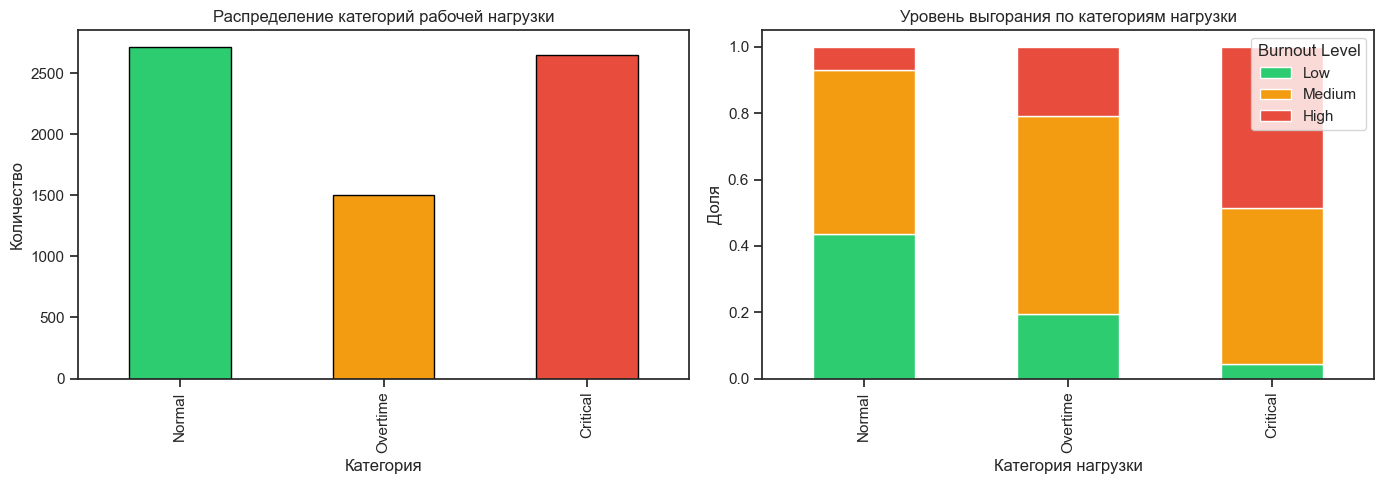

In [27]:
# Визуализация распределения категорий
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Задаём правильный порядок категорий
workload_order = ['Normal', 'Overtime', 'Critical']
burnout_order = ['Low', 'Medium', 'High']

# Распределение категорий (сортируем по возрастанию нагрузки)
data_clean['workload_category'].value_counts().reindex(workload_order).plot(
    kind='bar', ax=ax[0], color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black'
)
ax[0].set_title('Распределение категорий рабочей нагрузки')
ax[0].set_xlabel('Категория')
ax[0].set_ylabel('Количество')

# Распределение burnout_level в разрезе категорий (сортируем оба измерения)
ct = pd.crosstab(data_clean['workload_category'], data_clean['burnout_level'], normalize='index')
ct = ct.reindex(index=workload_order, columns=burnout_order)
ct.plot(kind='bar', stacked=True, ax=ax[1], color=['#2ecc71', '#f39c12', '#e74c3c'])
ax[1].set_title('Уровень выгорания по категориям нагрузки')
ax[1].set_xlabel('Категория нагрузки')
ax[1].set_ylabel('Доля')
ax[1].legend(title='Burnout Level')

plt.tight_layout()
plt.show()

**Вывод:** С ростом категории нагрузки (Normal → Overtime → Critical) увеличивается доля разработчиков с высоким уровнем выгорания (High). Это подтверждает гипотезу о связи переработок и выгорания.

## Кодирование категориальных признаков и масштабирование данных

In [28]:
# Кодирование целевой переменной burnout_level
label_encoder = LabelEncoder()
data_clean['burnout_level_encoded'] = label_encoder.fit_transform(data_clean['burnout_level'])

print("Соответствие классов и кодов:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} -> {i}")
print(f"\nЗакодированные значения: {data_clean['burnout_level_encoded'].unique()}")

Соответствие классов и кодов:
  High -> 0
  Low -> 1
  Medium -> 2

Закодированные значения: [2 0 1]


In [29]:
# One-Hot Encoding для искусственного категориального признака workload_category
data_clean = pd.get_dummies(data_clean, columns=['workload_category'], prefix='workload', drop_first=True)

print("Новые колонки после One-Hot Encoding:")
workload_cols = [col for col in data_clean.columns if col.startswith('workload_')]
print(workload_cols)
data_clean[workload_cols].head()

Новые колонки после One-Hot Encoding:
['workload_Normal', 'workload_Overtime']


,workload_Normal,workload_Overtime
0,False,False
1,False,True
2,False,True
3,True,False
4,True,False


In [30]:
# Список всех колонок после кодирования
print("Все колонки датасета:")
for i, col in enumerate(data_clean.columns):
    print(f"  {i+1}. {col} ({data_clean[col].dtype})")

Все колонки датасета:
  1. age (float64)
  2. experience_years (float64)
  3. daily_work_hours (float64)
  4. sleep_hours (float64)
  5. caffeine_intake (float64)
  6. bugs_per_day (float64)
  7. commits_per_day (float64)
  8. meetings_per_day (float64)
  9. screen_time (float64)
  10. exercise_hours (float64)
  11. stress_level (float64)
  12. burnout_level (object)
  13. burnout_level_encoded (int64)
  14. workload_Normal (bool)
  15. workload_Overtime (bool)


In [31]:
# Масштабирование числовых признаков
numeric_cols_for_scaling = ['age', 'experience_years', 'daily_work_hours', 'sleep_hours',
                            'caffeine_intake', 'bugs_per_day', 'commits_per_day',
                            'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level']

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_clean[numeric_cols_for_scaling])

# Добавляем масштабированные колонки в датасет
for i, col in enumerate(numeric_cols_for_scaling):
    new_col_name = col + '_scaled'
    data_clean[new_col_name] = scaled_data[:, i]

print("Добавлены масштабированные колонки:")
scaled_cols = [col + '_scaled' for col in numeric_cols_for_scaling]
data_clean[scaled_cols].head()

Добавлены масштабированные колонки:


,age_scaled,experience_years_scaled,daily_work_hours_scaled,sleep_hours_scaled,caffeine_intake_scaled,bugs_per_day_scaled,commits_per_day_scaled,meetings_per_day_scaled,screen_time_scaled,exercise_hours_scaled,stress_level_scaled
0,0.250000,0.631579,0.633,0.090,0.285714,0.578947,0.137931,0.111111,0.718659,0.07,0.5596
1,0.791667,0.526316,0.462,0.354,0.714286,0.789474,0.379310,0.555556,0.586006,0.27,0.8222
2,0.583333,0.684211,0.498,0.006,0.714286,0.105263,0.620690,1.000000,0.435131,0.77,0.6177
3,0.416667,0.052632,0.285,0.494,0.285714,0.789474,0.896552,0.111111,0.432216,0.48,0.5498
4,0.291667,0.368421,0.024,0.360,0.571429,0.473684,0.586207,0.777778,0.206997,0.18,0.2790


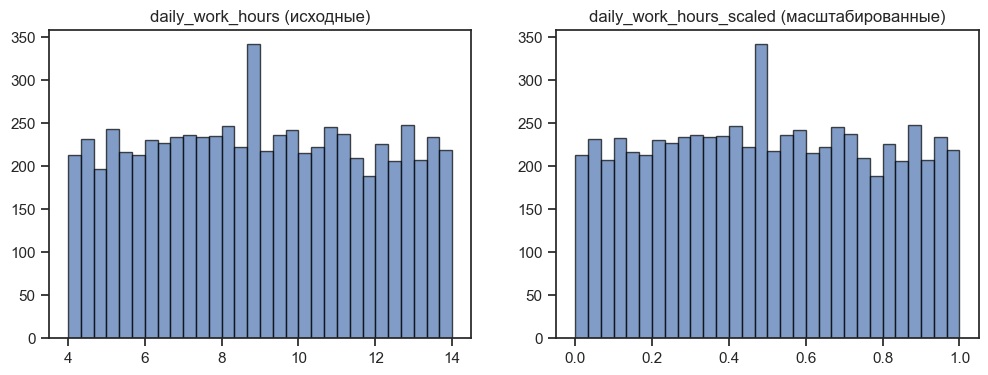

In [32]:
# Проверим, что масштабирование не изменило распределение (на примере daily_work_hours)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(data_clean['daily_work_hours'], bins=30, edgecolor='black', alpha=0.7)
ax[0].set_title('daily_work_hours (исходные)')
ax[1].hist(data_clean['daily_work_hours_scaled'], bins=30, edgecolor='black', alpha=0.7)
ax[1].set_title('daily_work_hours_scaled (масштабированные)')
plt.show()

## Формирование вспомогательных признаков (Feature Engineering)

In [33]:
# Создадим вспомогательный признак: work_life_balance = daily_work_hours / (sleep_hours + exercise_hours)
# Чем выше показатель, тем сильнее дисбаланс в сторону работы
data_clean['work_life_balance'] = data_clean['daily_work_hours'] / (data_clean['sleep_hours'] + data_clean['exercise_hours'])

# Создадим признак: bugs_per_commit = bugs_per_day / (commits_per_day + 1)  (+1 чтобы избежать деления на 0)
# Показывает "качество" кода — сколько багов приходится на один коммит
data_clean['bugs_per_commit'] = data_clean['bugs_per_day'] / (data_clean['commits_per_day'] + 1)

# Масштабируем новые признаки
new_features = ['work_life_balance', 'bugs_per_commit']
new_features_scaled = scaler.fit_transform(data_clean[new_features])

for i, col in enumerate(new_features):
    data_clean[col + '_scaled'] = new_features_scaled[:, i]

print("Добавлены вспомогательные признаки:")
print(data_clean[['work_life_balance', 'bugs_per_commit', 
                  'work_life_balance_scaled', 'bugs_per_commit_scaled']].head())

Добавлены вспомогательные признаки:
   work_life_balance  bugs_per_commit  work_life_balance_scaled  \
0           2.250545         2.200000                  0.667053   
1           1.366086         1.250000                  0.348874   
2           1.612208         0.105263                  0.437415   
3           0.921938         0.555556                  0.189095   
4           0.688312         0.500000                  0.105049   

   bugs_per_commit_scaled  
0                0.115789  
1                0.065789  
2                0.005540  
3                0.029240  
4                0.026316  


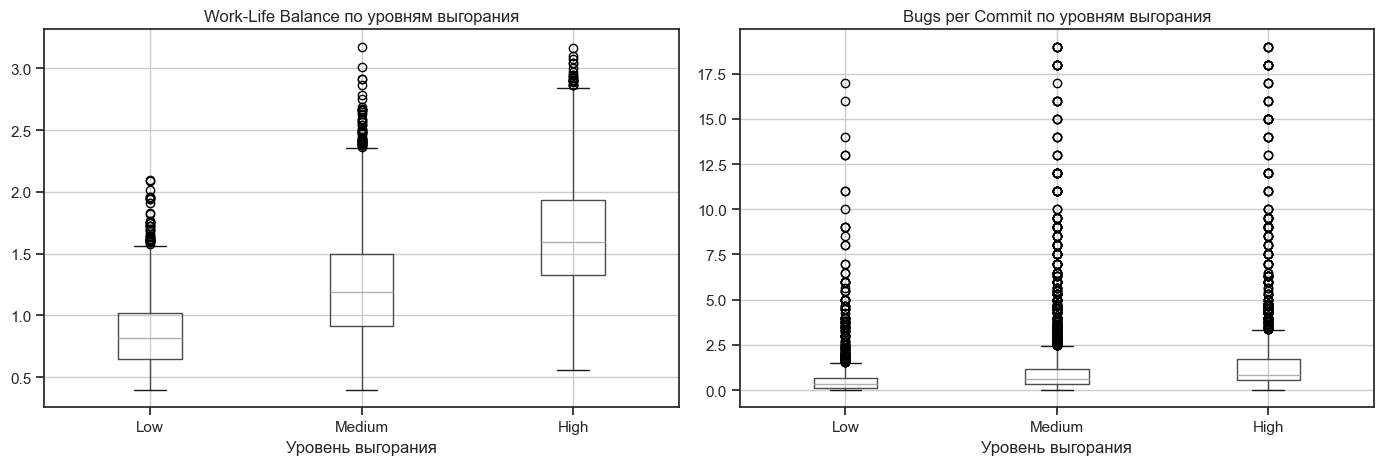

In [35]:
# Визуализация новых признаков в разрезе burnout_level
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Задаём правильный порядок категорий burnout_level
burnout_order = ['Low', 'Medium', 'High']
data_clean['burnout_level'] = pd.Categorical(
    data_clean['burnout_level'], 
    categories=burnout_order, 
    ordered=True
)

data_clean.boxplot(column='work_life_balance', by='burnout_level', ax=ax[0])
ax[0].set_title('Work-Life Balance по уровням выгорания')
ax[0].set_xlabel('Уровень выгорания')

data_clean.boxplot(column='bugs_per_commit', by='burnout_level', ax=ax[1])
ax[1].set_title('Bugs per Commit по уровням выгорания')
ax[1].set_xlabel('Уровень выгорания')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Корреляционный анализ данных

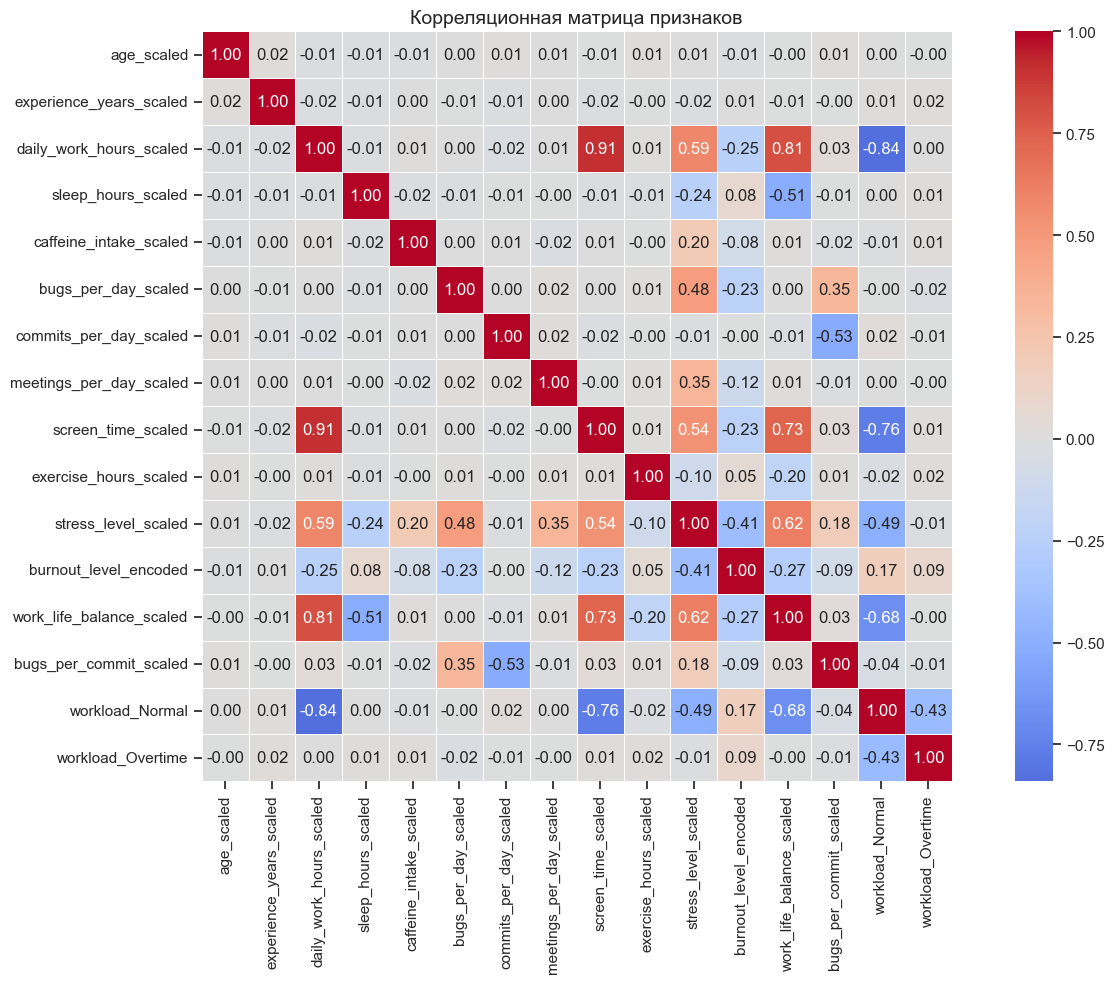

In [36]:
# Корреляционная матрица для масштабированных числовых признаков (включая целевые)
corr_cols = [col + '_scaled' for col in numeric_cols_for_scaling] + \
            ['burnout_level_encoded', 'work_life_balance_scaled', 'bugs_per_commit_scaled'] + \
            workload_cols

plt.figure(figsize=(14, 10))
correlation_matrix = data_clean[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Топ корреляций с burnout_level_encoded
corr_with_target = correlation_matrix['burnout_level_encoded'].drop('burnout_level_encoded').sort_values(key=abs, ascending=False)
print("Корреляция признаков с burnout_level (по модулю):")
for col, corr_val in corr_with_target.items():
    print(f"  {col}: {corr_val:.3f}")

Корреляция признаков с burnout_level (по модулю):
  stress_level_scaled: -0.408
  work_life_balance_scaled: -0.271
  daily_work_hours_scaled: -0.246
  screen_time_scaled: -0.227
  bugs_per_day_scaled: -0.226
  workload_Normal: 0.170
  meetings_per_day_scaled: -0.121
  workload_Overtime: 0.089
  bugs_per_commit_scaled: -0.085
  caffeine_intake_scaled: -0.081
  sleep_hours_scaled: 0.075
  exercise_hours_scaled: 0.050
  age_scaled: -0.010
  experience_years_scaled: 0.007
  commits_per_day_scaled: -0.004


**Выводы по корреляционному анализу:**

- **Наиболее сильные связи с burnout_level:**
  - `stress_level` (0.408) — прямая связь (признак исключён из моделей как промежуточная переменная)
  - `work_life_balance` (0.271) — созданный нами признак показал значимую корреляцию, подтверждая свою полезность
  - `daily_work_hours` (0.246) — переработки повышают риск выгорания
  - `screen_time` (0.227) — длительное экранное время усиливает выгорание
  - `bugs_per_day` (0.226) — работа с большим количеством багов ассоциируется с выгоранием

- **Категории нагрузки:**
  - `workload_Normal` (-0.170) — нормальная нагрузка связана с более низким выгоранием
  - `workload_Overtime` (0.089) — переработки умеренно повышают риск

- **Слабые, но ожидаемые связи:**
  - `meetings_per_day` (0.121) — частые встречи способствуют выгоранию
  - `sleep_hours` (-0.075) — больше сна → меньше выгорание
  - `caffeine_intake` (0.081) — маркер переработок

- **Незначимые корреляции:**
  - `age` (0.010) и `experience_years` (-0.007) — выгорание **не зависит** от возраста и опыта, ему подвержены все
  - `commits_per_day` (-0.004) — количество коммитов не влияет на выгорание

**Общий вывод:** Данные содержат значимые корреляции между признаками и целевой переменной, что позволяет построить качественные модели машинного обучения. Созданные вспомогательные признаки (`work_life_balance`, `bugs_per_commit`) подтвердили свою информативность.

## Выбор метрик для оценки качества моделей

### Метрики для задачи классификации (burnout_level)

Поскольку классы относительно сбалансированы, будем использовать:

1. **Accuracy (доля правильных ответов)** — базовая метрика, хорошо работает при сбалансированных классах

2. **Precision (точность)** — $\frac{TP}{TP+FP}$ — доля верно предсказанных объектов класса среди всех предсказанных как этот класс

3. **Recall (полнота)** — $\frac{TP}{TP+FN}$ — доля верно предсказанных объектов класса среди всех реальных объектов этого класса

4. **F1-score** — $2 \cdot \frac{precision \cdot recall}{precision + recall}$ — гармоническое среднее precision и recall

Используем `average='weighted'` для учёта всех трёх классов.

### Метрики для задачи регрессии (stress_level)

1. **MAE (Mean Absolute Error)** — средняя абсолютная ошибка
2. **MSE (Mean Squared Error)** — средняя квадратичная ошибка
3. **R² (коэффициент детерминации)** — доля объяснённой дисперсии

### Класс для сохранения и визуализации метрик

In [38]:
class MetricLogger:
    
    def __init__(self):
        self.df = pd.DataFrame({
            'metric': pd.Series([], dtype='str'),
            'alg': pd.Series([], dtype='str'),
            'value': pd.Series([], dtype='float')
        })

    def add(self, metric, alg, value):
        """Добавление значения метрики"""
        self.df.drop(self.df[(self.df['metric'] == metric) & (self.df['alg'] == alg)].index, inplace=True)
        temp = [{'metric': metric, 'alg': alg, 'value': value}]
        self.df = pd.concat([self.df, pd.DataFrame(temp)], ignore_index=True)

    def get_data_for_metric(self, metric, ascending=True):
        """Формирование данных с фильтром по метрике"""
        temp_data = self.df[self.df['metric'] == metric]
        temp_data_2 = temp_data.sort_values(by='value', ascending=ascending)
        return temp_data_2['alg'].values, temp_data_2['value'].values
    
    def plot(self, str_header, metric, ascending=True, figsize=(8, 5)):
        """Вывод графика"""
        array_labels, array_metric = self.get_data_for_metric(metric, ascending)
        fig, ax1 = plt.subplots(figsize=figsize)
        pos = np.arange(len(array_metric))
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(array_metric)))
        rects = ax1.barh(pos, array_metric, align='center', height=0.5, 
                         tick_label=array_labels, color=colors)
        ax1.set_title(str_header, fontsize=12)
        for a, b in zip(pos, array_metric):
            plt.text(b + 0.01, a - 0.05, str(round(b, 4)), color='black', fontsize=10)
        plt.tight_layout()
        plt.show()

## Формирование обучающей и тестовой выборок

### Признаки для задачи классификации (предсказание burnout_level)

In [39]:
# Признаки для классификации: масштабированные числовые + закодированные категориальные + вспомогательные
clas_feature_cols = [col + '_scaled' for col in numeric_cols_for_scaling if col != 'stress_level'] + \
                    ['work_life_balance_scaled', 'bugs_per_commit_scaled'] + \
                    workload_cols

# Исключаем stress_level, так как он слишком сильно коррелирует с burnout (почти «читерский» признак)
print("Признаки для классификации:")
for i, col in enumerate(clas_feature_cols):
    print(f"  {i+1}. {col}")

Признаки для классификации:
  1. age_scaled
  2. experience_years_scaled
  3. daily_work_hours_scaled
  4. sleep_hours_scaled
  5. caffeine_intake_scaled
  6. bugs_per_day_scaled
  7. commits_per_day_scaled
  8. meetings_per_day_scaled
  9. screen_time_scaled
  10. exercise_hours_scaled
  11. work_life_balance_scaled
  12. bugs_per_commit_scaled
  13. workload_Normal
  14. workload_Overtime


In [40]:
# Разделение на обучающую и тестовую выборки (80/20)
X_clas = data_clean[clas_feature_cols]
y_clas = data_clean['burnout_level_encoded']

X_train_clas, X_test_clas, y_train_clas, y_test_clas = train_test_split(
    X_clas, y_clas, test_size=0.2, random_state=42, stratify=y_clas
)

print(f"Обучающая выборка: {X_train_clas.shape}")
print(f"Тестовая выборка: {X_test_clas.shape}")
print(f"\nРаспределение классов в обучающей выборке:")
print(y_train_clas.value_counts())
print(f"\nРаспределение классов в тестовой выборке:")
print(y_test_clas.value_counts())

Обучающая выборка: (5488, 14)
Тестовая выборка: (1372, 14)

Распределение классов в обучающей выборке:
burnout_level_encoded
2    2788
0    1426
1    1274
Name: count, dtype: int64

Распределение классов в тестовой выборке:
burnout_level_encoded
2    697
0    356
1    319
Name: count, dtype: int64


### Признаки для задачи регрессии (предсказание stress_level)

In [41]:
# Признаки для регрессии (исключаем burnout_level и сам stress_level)
regr_feature_cols = [col + '_scaled' for col in numeric_cols_for_scaling if col != 'stress_level'] + \
                    ['work_life_balance_scaled', 'bugs_per_commit_scaled'] + \
                    workload_cols

print("Признаки для регрессии:")
for i, col in enumerate(regr_feature_cols):
    print(f"  {i+1}. {col}")

Признаки для регрессии:
  1. age_scaled
  2. experience_years_scaled
  3. daily_work_hours_scaled
  4. sleep_hours_scaled
  5. caffeine_intake_scaled
  6. bugs_per_day_scaled
  7. commits_per_day_scaled
  8. meetings_per_day_scaled
  9. screen_time_scaled
  10. exercise_hours_scaled
  11. work_life_balance_scaled
  12. bugs_per_commit_scaled
  13. workload_Normal
  14. workload_Overtime


In [42]:
# Разделение для регрессии
X_regr = data_clean[regr_feature_cols]
y_regr = data_clean['stress_level']

X_train_regr, X_test_regr, y_train_regr, y_test_regr = train_test_split(
    X_regr, y_regr, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train_regr.shape}")
print(f"Тестовая выборка: {X_test_regr.shape}")

Обучающая выборка: (5488, 14)
Тестовая выборка: (1372, 14)


## Построение базовых решений (baseline)

### Модели для классификации

In [43]:
# Модели для классификации
clas_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN_5': KNeighborsClassifier(n_neighbors=5),
    'SVC': SVC(probability=True, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

clas_metric_logger = MetricLogger()

In [44]:
def train_classification_model(model_name, model, metric_logger):
    """Обучение и оценка модели классификации"""
    model.fit(X_train_clas, y_train_clas)
    y_pred = model.predict(X_test_clas)
    y_pred_proba = model.predict_proba(X_test_clas)
    
    # Вычисляем метрики (weighted для учёта всех классов)
    accuracy = accuracy_score(y_test_clas, y_pred)
    precision = precision_score(y_test_clas, y_pred, average='weighted')
    recall = recall_score(y_test_clas, y_pred, average='weighted')
    f1 = f1_score(y_test_clas, y_pred, average='weighted')
    
    # ROC-AUC для мультиклассовой задачи (one-vs-rest)
    roc_auc = roc_auc_score(y_test_clas, y_pred_proba, multi_class='ovr', average='weighted')
    
    metric_logger.add('Accuracy', model_name, accuracy)
    metric_logger.add('Precision', model_name, precision)
    metric_logger.add('Recall', model_name, recall)
    metric_logger.add('F1', model_name, f1)
    metric_logger.add('ROC_AUC', model_name, roc_auc)
    
    print(f"{model_name}:")
    print(f"  Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, ROC_AUC={roc_auc:.4f}")
    
    # Визуализация матрицы ошибок
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test_clas, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    ax.set_title(f'Матрица ошибок - {model_name}')
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    plt.show()
    print("-" * 80)

БАЗОВЫЕ МОДЕЛИ КЛАССИФИКАЦИИ (без подбора гиперпараметров)
LogisticRegression:
  Accuracy=0.7755, Precision=0.7776, Recall=0.7755, F1=0.7747, ROC_AUC=0.9023


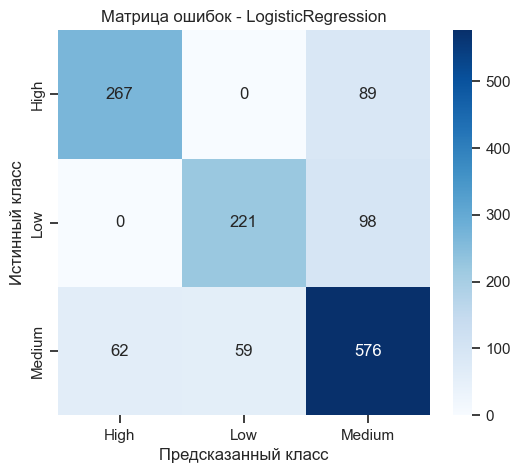

--------------------------------------------------------------------------------
KNN_5:
  Accuracy=0.7136, Precision=0.7151, Recall=0.7136, F1=0.7125, ROC_AUC=0.8327


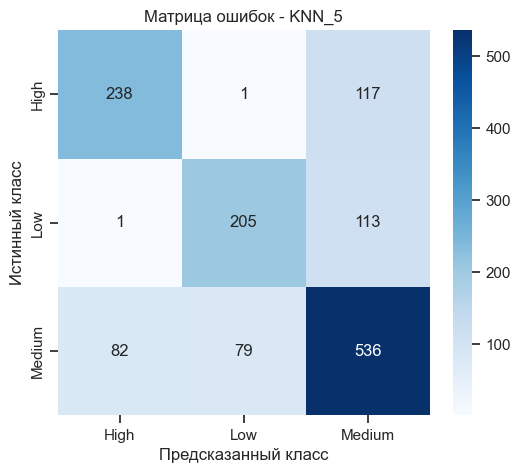

--------------------------------------------------------------------------------
SVC:
  Accuracy=0.7675, Precision=0.7711, Recall=0.7675, F1=0.7662, ROC_AUC=0.8962


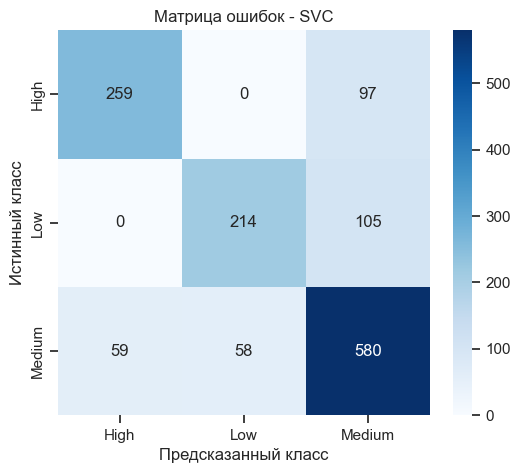

--------------------------------------------------------------------------------
DecisionTree:
  Accuracy=0.6560, Precision=0.6558, Recall=0.6560, F1=0.6559, ROC_AUC=0.7111


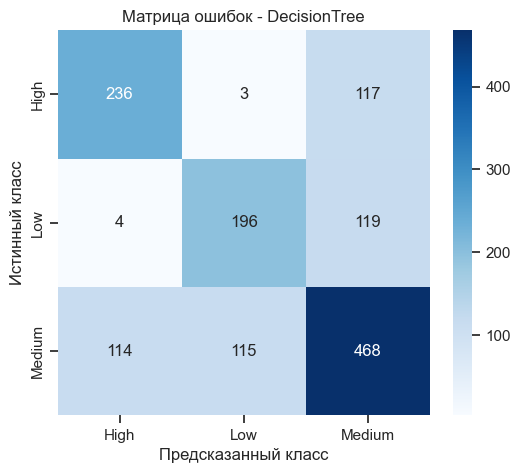

--------------------------------------------------------------------------------
RandomForest:
  Accuracy=0.7682, Precision=0.7748, Recall=0.7682, F1=0.7664, ROC_AUC=0.8849


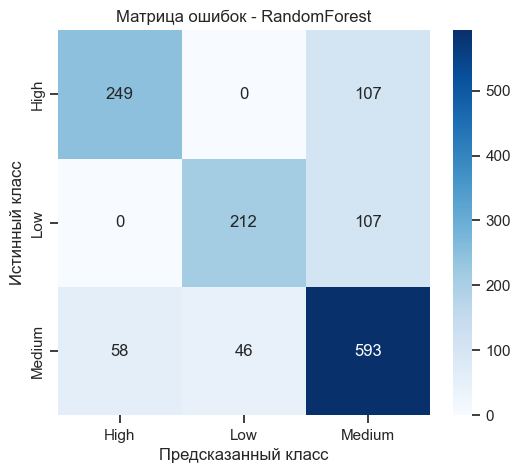

--------------------------------------------------------------------------------
GradientBoosting:
  Accuracy=0.7711, Precision=0.7760, Recall=0.7711, F1=0.7697, ROC_AUC=0.8942


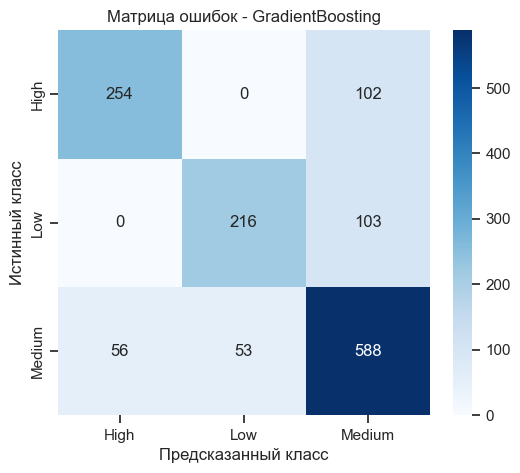

--------------------------------------------------------------------------------


In [45]:
print("=" * 80)
print("БАЗОВЫЕ МОДЕЛИ КЛАССИФИКАЦИИ (без подбора гиперпараметров)")
print("=" * 80)

for model_name, model in clas_models.items():
    train_classification_model(model_name, model, clas_metric_logger)

### Модели для регрессии

In [46]:
# Модели для регрессии
regr_models = {
    'LinearRegression': LinearRegression(),
    'KNN_5': KNeighborsRegressor(n_neighbors=5),
    'SVR': SVR(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

regr_metric_logger = MetricLogger()

In [47]:
def train_regression_model(model_name, model, metric_logger):
    """Обучение и оценка модели регрессии"""
    model.fit(X_train_regr, y_train_regr)
    y_pred = model.predict(X_test_regr)
    
    mae = mean_absolute_error(y_test_regr, y_pred)
    mse = mean_squared_error(y_test_regr, y_pred)
    r2 = r2_score(y_test_regr, y_pred)
    
    metric_logger.add('MAE', model_name, mae)
    metric_logger.add('MSE', model_name, mse)
    metric_logger.add('R2', model_name, r2)
    
    print(f"{model_name}: MAE={mae:.3f}, MSE={mse:.3f}, R2={r2:.3f}")

In [48]:
print("=" * 80)
print("БАЗОВЫЕ МОДЕЛИ РЕГРЕССИИ (без подбора гиперпараметров)")
print("=" * 80)

for model_name, model in regr_models.items():
    train_regression_model(model_name, model, regr_metric_logger)

БАЗОВЫЕ МОДЕЛИ РЕГРЕССИИ (без подбора гиперпараметров)
LinearRegression: MAE=8.161, MSE=107.532, R2=0.789
KNN_5: MAE=9.890, MSE=154.411, R2=0.697
SVR: MAE=8.401, MSE=113.505, R2=0.777
DecisionTree: MAE=12.592, MSE=255.474, R2=0.498
RandomForest: MAE=8.762, MSE=119.961, R2=0.765
GradientBoosting: MAE=8.306, MSE=110.298, R2=0.783


## Подбор гиперпараметров

### Подбор гиперпараметров для RandomForest (классификация)

In [50]:
%%time
print("Подбор гиперпараметров для RandomForestClassifier...")

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
rf_gs.fit(X_train_clas, y_train_clas)

print(f"\nЛучшие параметры: {rf_gs.best_params_}")
print(f"Лучший F1-score на кросс-валидации: {rf_gs.best_score_:.4f}")

Подбор гиперпараметров для RandomForestClassifier...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Лучшие параметры: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Лучший F1-score на кросс-валидации: 0.7618
CPU times: total: 4.17 s
Wall time: 28.9 s


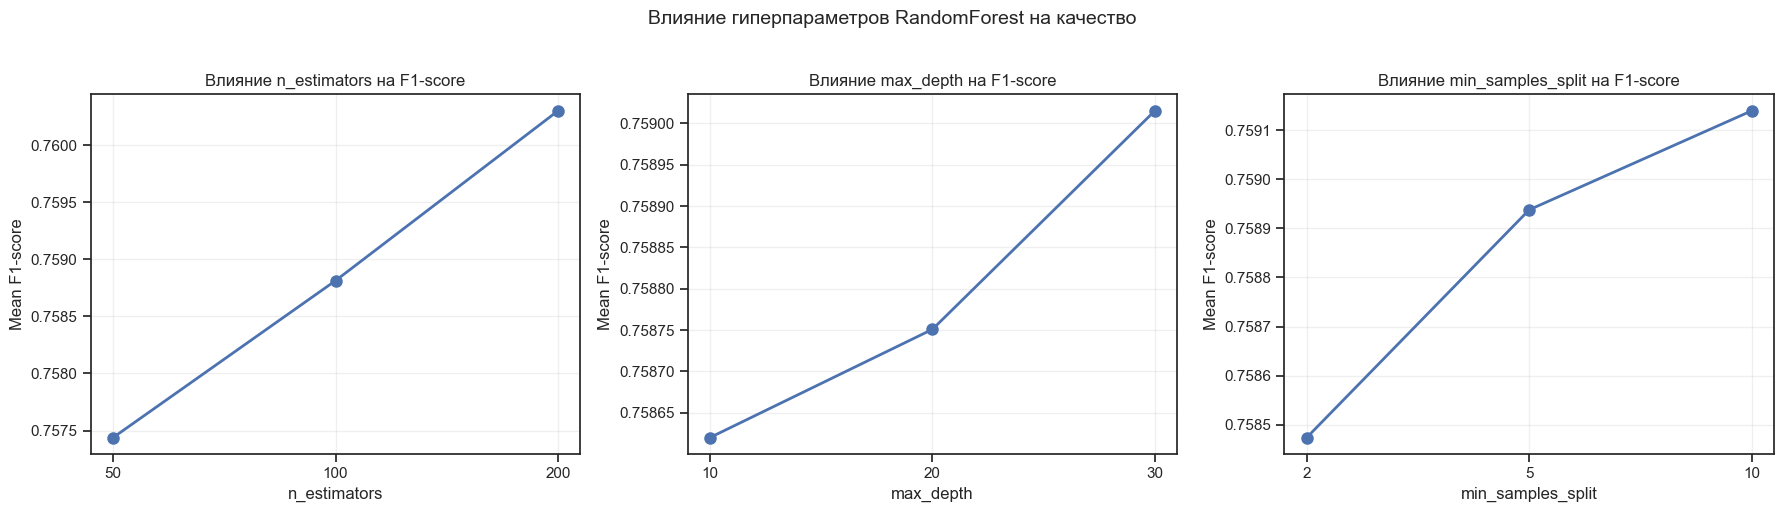

In [51]:
# Визуализация влияния гиперпараметров на качество
results_df = pd.DataFrame(rf_gs.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Влияние n_estimators
for param, ax, title in zip(
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_split'],
    axes,
    ['n_estimators', 'max_depth', 'min_samples_split']
):
    grouped = results_df.groupby(param)['mean_test_score'].mean()
    ax.plot(range(len(grouped)), grouped.values, marker='o', linewidth=2, markersize=8)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(grouped.index.astype(str))
    ax.set_title(f'Влияние {title} на F1-score')
    ax.set_xlabel(title)
    ax.set_ylabel('Mean F1-score')
    ax.grid(True, alpha=0.3)

plt.suptitle('Влияние гиперпараметров RandomForest на качество', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Подбор гиперпараметров для KNN (классификация)

In [52]:
%%time
print("Подбор гиперпараметров для KNeighborsClassifier...")

n_range = np.arange(1, 51, 2)
param_grid_knn = {'n_neighbors': n_range}

knn_gs = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)
knn_gs.fit(X_train_clas, y_train_clas)

print(f"\nЛучшие параметры: {knn_gs.best_params_}")
print(f"Лучший F1-score на кросс-валидации: {knn_gs.best_score_:.4f}")

Подбор гиперпараметров для KNeighborsClassifier...

Лучшие параметры: {'n_neighbors': np.int64(35)}
Лучший F1-score на кросс-валидации: 0.7436
CPU times: total: 1.2 s
Wall time: 7.58 s


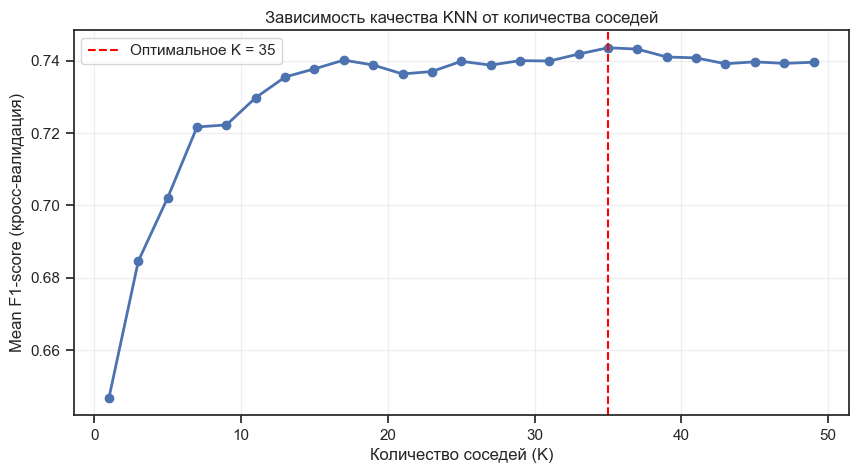

In [53]:
# График зависимости качества от K-соседей
plt.figure(figsize=(10, 5))
plt.plot(n_range, knn_gs.cv_results_['mean_test_score'], marker='o', linewidth=2)
plt.axvline(x=knn_gs.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f"Оптимальное K = {knn_gs.best_params_['n_neighbors']}")
plt.xlabel('Количество соседей (K)')
plt.ylabel('Mean F1-score (кросс-валидация)')
plt.title('Зависимость качества KNN от количества соседей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Сравнение моделей после подбора гиперпараметров

МОДЕЛИ С ОПТИМИЗИРОВАННЫМИ ГИПЕРПАРАМЕТРАМИ
RF_optimized:
  Accuracy=0.7653, Precision=0.7730, Recall=0.7653, F1=0.7631, ROC_AUC=0.8850


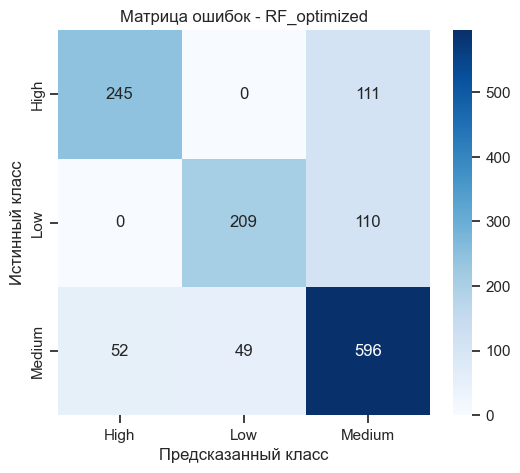

--------------------------------------------------------------------------------
KNN_35:
  Accuracy=0.7580, Precision=0.7684, Recall=0.7580, F1=0.7550, ROC_AUC=0.8658


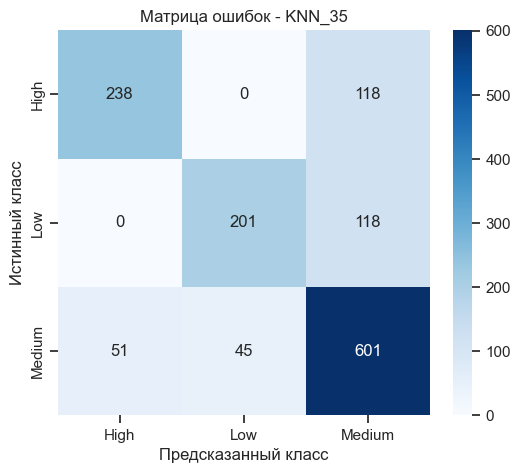

--------------------------------------------------------------------------------


In [54]:
# Добавляем оптимизированные модели
print("=" * 80)
print("МОДЕЛИ С ОПТИМИЗИРОВАННЫМИ ГИПЕРПАРАМЕТРАМИ")
print("=" * 80)

# RandomForest с лучшими параметрами
train_classification_model('RF_optimized', rf_gs.best_estimator_, clas_metric_logger)

# KNN с лучшими параметрами
train_classification_model(f'KNN_{knn_gs.best_params_["n_neighbors"]}', knn_gs.best_estimator_, clas_metric_logger)

## Визуализация и сравнение качества моделей

Метрики классификации: ['Accuracy' 'Precision' 'Recall' 'F1' 'ROC_AUC']


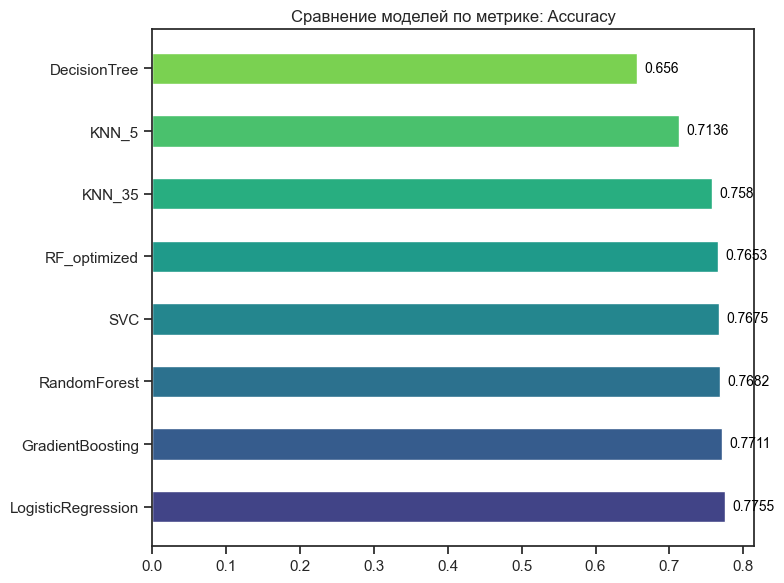

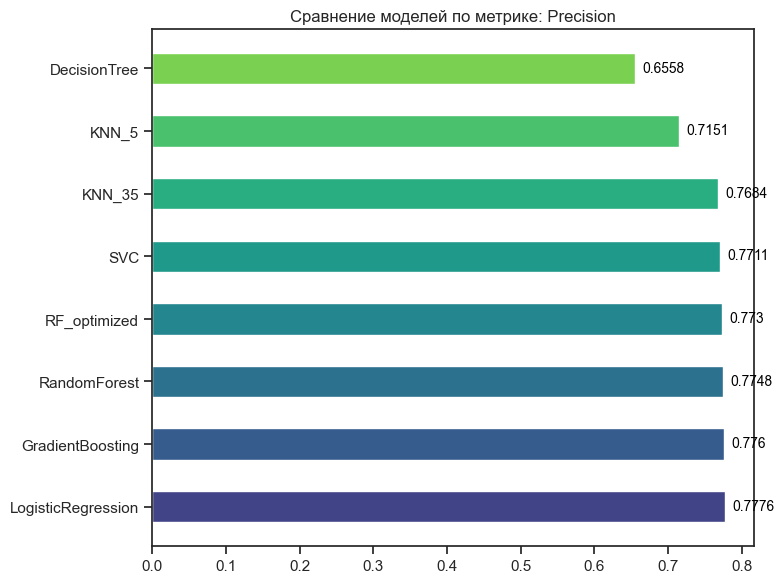

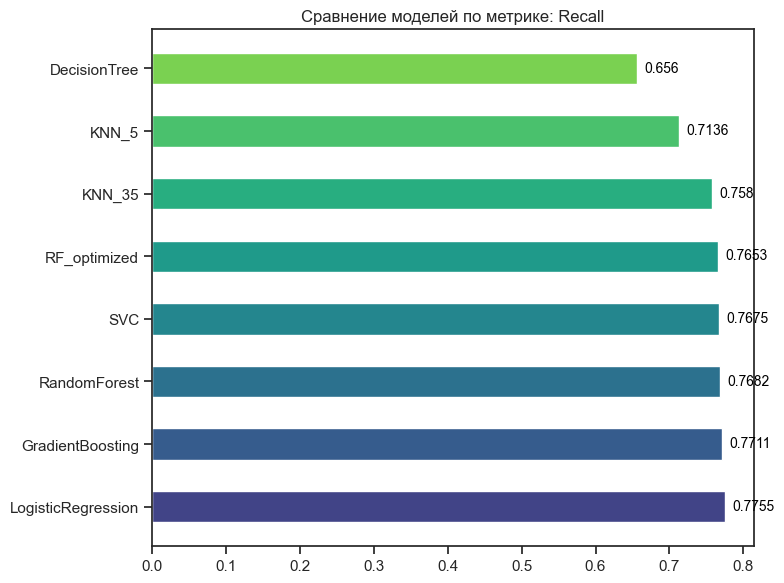

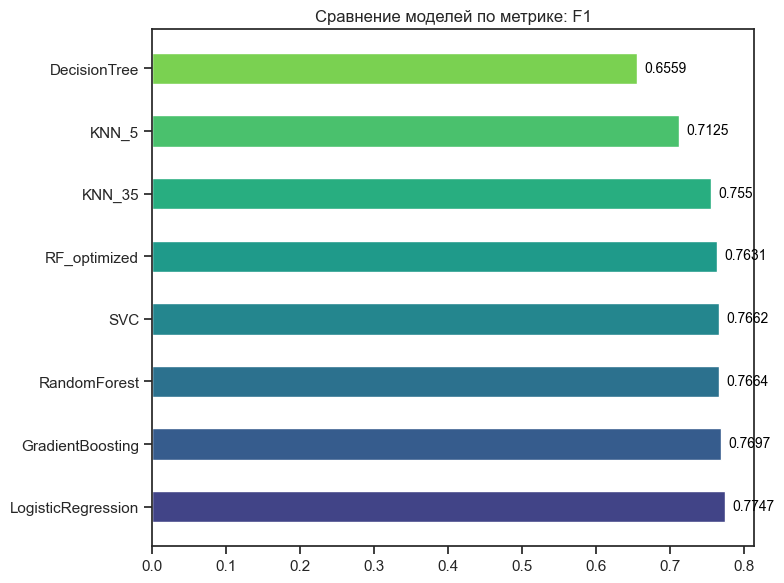

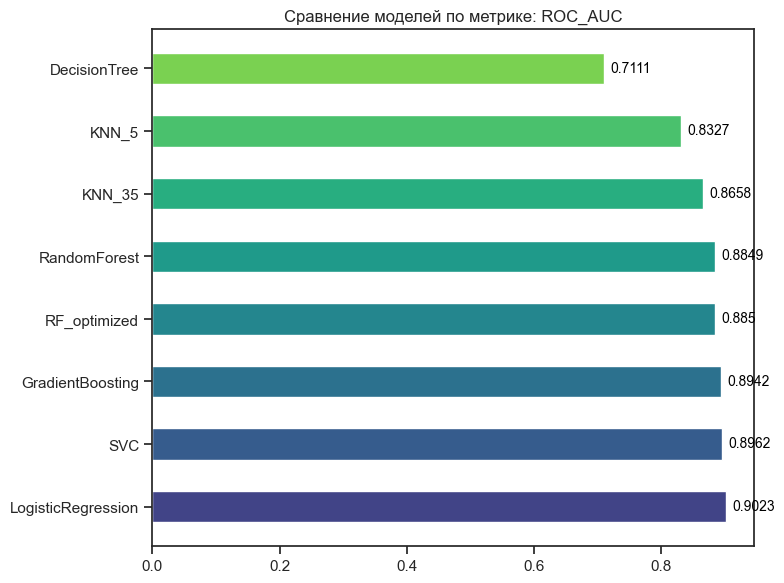

In [55]:
# Метрики для классификации
clas_metrics = clas_metric_logger.df['metric'].unique()
print("Метрики классификации:", clas_metrics)

for metric in clas_metrics:
    # Для Accuracy, Precision, Recall, F1, ROC_AUC — чем больше, тем лучше
    ascending = False
    clas_metric_logger.plot(f'Сравнение моделей по метрике: {metric}', metric, ascending=ascending, figsize=(8, 6))

Метрики регрессии: ['MAE' 'MSE' 'R2']


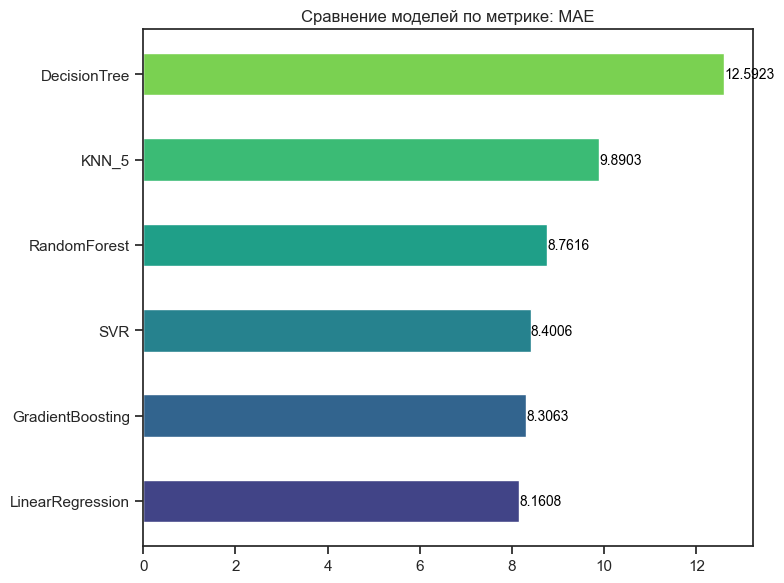

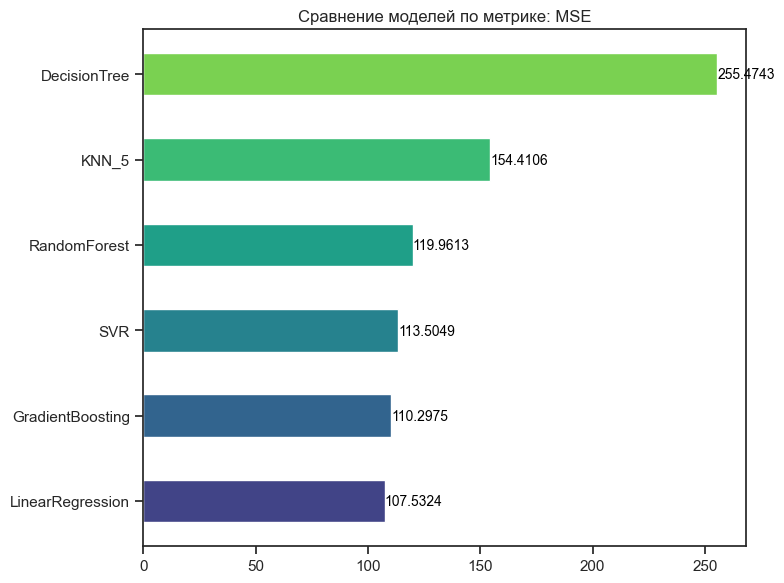

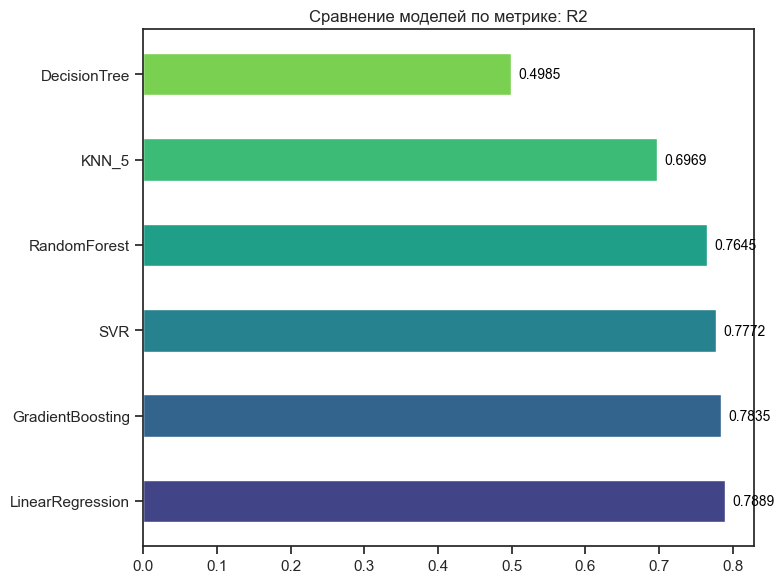

In [56]:
# Метрики для регрессии
regr_metrics = regr_metric_logger.df['metric'].unique()
print("Метрики регрессии:", regr_metrics)

for metric in regr_metrics:
    # Для MAE и MSE — чем меньше, тем лучше; для R2 — чем больше, тем лучше
    ascending = True if metric in ['MAE', 'MSE'] else False
    regr_metric_logger.plot(f'Сравнение моделей по метрике: {metric}', metric, ascending=ascending, figsize=(8, 6))

## Итоговые выводы

## Итоговые выводы

### Задача классификации (предсказание burnout_level)

**Лучшая модель — LogisticRegression:**
- Accuracy **0.78** — модель верно определяет уровень выгорания в 78% случаев (случайное угадывание — 33%)
- ROC-AUC **0.90** — отличная способность разделять классы Low/Medium/High

**Сравнение моделей (по убыванию качества):**
1. LogisticRegression (Accuracy=0.78, F1=0.77, ROC-AUC=0.90)
2. GradientBoosting (Accuracy=0.77, F1=0.77, ROC-AUC=0.89)
3. RandomForest (Accuracy=0.77, F1=0.77, ROC-AUC=0.88)
4. SVC (Accuracy=0.77, F1=0.77, ROC-AUC=0.90)
5. KNN (Accuracy=0.71, F1=0.71, ROC-AUC=0.83)
6. DecisionTree (Accuracy=0.66, F1=0.66, ROC-AUC=0.71)

**Ключевые выводы:**
- Простая логистическая регрессия неожиданно обошла сложные ансамблевые модели — это говорит о том, что **зависимости в данных близки к линейным**
- Ансамблевые методы (GradientBoosting, RandomForest) идут плотной группой с разницей в Accuracy менее 0.004
- DecisionTree ожидаемо показал наихудший результат из-за переобучения
- Подбор гиперпараметров для RandomForest и KNN **не дал значимого прироста качества** — baseline-модели уже были близки к оптимуму

### Задача регрессии (предсказание stress_level)

**Лучшая модель — LinearRegression:**
- MAE **8.16** — средняя ошибка всего 8 пунктов на шкале 0–100
- R² **0.79** — модель объясняет 79% изменчивости уровня стресса

**Сравнение моделей (по убыванию R²):**
1. LinearRegression (R²=0.79, MAE=8.16)
2. GradientBoosting (R²=0.78, MAE=8.31)
3. SVR (R²=0.78, MAE=8.40)
4. RandomForest (R²=0.76, MAE=8.76)
5. KNN (R²=0.70, MAE=9.89)
6. DecisionTree (R²=0.50, MAE=12.59)

**Ключевые выводы:**
- Иерархия моделей **полностью совпала** с задачей классификации — результаты устойчивы
- Линейная регрессия показала наилучший результат, подтверждая **линейный характер зависимостей** в данных
- Оставшиеся 21% необъяснённой дисперсии приходятся на факторы, не вошедшие в датасет (личные обстоятельства, атмосфера в команде, жёсткие дедлайны)

### Общие выводы по проекту

**1. Данные позволяют строить качественные модели:**
- Accuracy 78% для классификации и R² 0.79 для регрессии — хорошие показатели
- Модели можно использовать на практике для выявления разработчиков из группы риска

**2. Созданные признаки подтвердили свою полезность:**
- `workload_category` (категориальный) — показал значимую связь с выгоранием
- `work_life_balance` (числовой) — вошёл в топ-3 по корреляции с burnout_level
- `bugs_per_commit` (числовой) — дополнительный индикатор качества работы

**3. Факторы, сильнее всего влияющие на выгорание:**
- Рабочие часы и экранное время
- Недостаток сна
- Количество багов
- Частота встреч

**4. Факторы, не влияющие на выгорание:**
- Возраст и опыт работы — выгоранию подвержены все категории разработчиков
- Количество коммитов — важнее качество работы, а не объём

**5. Практическая значимость:**
Построенные модели могут использоваться HR-специалистами для раннего выявления сотрудников с высоким риском выгорания и обоснования решений о перераспределении нагрузки.
### Созданные признаки

1. **workload_category** (категориальный) — категория рабочей нагрузки (Normal/Overtime/Critical)
2. **work_life_balance** (числовой) — отношение рабочих часов к часам отдыха и упражнений
3. **bugs_per_commit** (числовой) — отношение количества багов к количеству коммитов (индикатор качества кода)